# LeetCode #4: Median of Two Sorted Arrays

https://leetcode.com/problems/median-of-two-sorted-arrays/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Merge and Find (Brute Force)** | $O(m + n)$ | $O(m + n)$ |
| **Binary Search on Partitions** | $O(\log(\min(m, n)))$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force: Merge and Find
Use two pointers to merge both arrays into a single sorted array, then read the middle index. Simple, but uses $O(m+n)$ extra space and violates the problem's explicit requirement for logarithmic time.

### Optimal: Binary Search on Partitions ★
Instead of merging, find a **partition point** in both arrays such that the combined left half and right half are balanced and correctly ordered — then read the median directly from the boundary values.

**Why this is the only viable optimal:** Any solution that reads all elements is $O(m+n)$. The partition technique is the key insight that achieves $O(\log(\min(m,n)))$ with no extra space.

---

## How the Partition Works

**pX** and **pY** are cut points — they split each array into a left half and a right half. Everything *before* the cut goes left; everything *at or after* goes right.

```
nums1 = [ 1 | 3  8 ]   pX = 1  → left: {1},    right: {3, 8}
nums2 = [ 2  5  9 | 11 ]  pY = 3  → left: {2,5,9}, right: {11}
```

**pY is never searched — it's always derived from pX:**
$$pY = \frac{m + n + 1}{2} - pX$$
Once you fix how many elements nums1 contributes to the left half (pX), the rest must come from nums2.

**Two conditions must both hold for the partition to be valid:**
1. `maxLeftX <= minRightY` — the largest element on nums1's left must not exceed the smallest on nums2's right.
2. `maxLeftY <= minRightX` — the largest element on nums2's left must not exceed the smallest on nums1's right.

Binary search adjusts pX until both conditions are satisfied. Use `int.MinValue` / `int.MaxValue` as sentinels when a partition sits at the edge of an array.

**Constraints:**
* $0 \le$ m, n $\le 1000$; total length $\ge 1$.
* The overall run time complexity should be $O(\log(m+n))$.

## Solutions

### C#

In [ ]:
using System;

public class Solution {
    public double FindMedianSortedArrays(int[] nums1, int[] nums2) {
        // Ensure we always binary search on the smaller array for O(log(min(m,n)))
        if (nums1.Length > nums2.Length) return FindMedianSortedArrays(nums2, nums1);

        int m = nums1.Length;
        int n = nums2.Length;
        int low = 0, high = m;

        while (low <= high) {
            int partitionX = (low + high) / 2;
            int partitionY = (m + n + 1) / 2 - partitionX;

            // If partitionX is 0, nothing on left. If m, nothing on right.
            int maxLeftX = (partitionX == 0) ? int.MinValue : nums1[partitionX - 1];
            int minRightX = (partitionX == m) ? int.MaxValue : nums1[partitionX];

            int maxLeftY = (partitionY == 0) ? int.MinValue : nums2[partitionY - 1];
            int minRightY = (partitionY == n) ? int.MaxValue : nums2[partitionY];

            if (maxLeftX <= minRightY && maxLeftY <= minRightX) {
                // We found the correct partition
                if ((m + n) % 2 == 0) {
                    return (Math.Max(maxLeftX, maxLeftY) + Math.Min(minRightX, minRightY)) / 2.0;
                } else {
                    return (double)Math.Max(maxLeftX, maxLeftY);
                }
            } else if (maxLeftX > minRightY) {
                // Move left in nums1
                high = partitionX - 1;
            } else {
                // Move right in nums1
                low = partitionX + 1;
            }
        }
        return 0.0;
    }
}

### Python

In [ ]:
class Solution:
    def findMedianSortedArrays(self, nums1: list[int], nums2: list[int]) -> float:
        # Ensure we always binary search on the smaller array for O(log(min(m,n)))
        if len(nums1) > len(nums2):
            return self.findMedianSortedArrays(nums2, nums1)

        m, n = len(nums1), len(nums2)
        low, high = 0, m

        while low <= high:
            partition_x = (low + high) // 2
            partition_y = (m + n + 1) // 2 - partition_x

            # If partitionX is 0, nothing on left. If m, nothing on right.
            max_left_x = float('-inf') if partition_x == 0 else nums1[partition_x - 1]
            min_right_x = float('inf') if partition_x == m else nums1[partition_x]

            max_left_y = float('-inf') if partition_y == 0 else nums2[partition_y - 1]
            min_right_y = float('inf') if partition_y == n else nums2[partition_y]

            if max_left_x <= min_right_y and max_left_y <= min_right_x:
                # We found the correct partition
                if (m + n) % 2 == 1:
                    return float(max(max_left_x, max_left_y))
                else:
                    return (max(max_left_x, max_left_y) + min(min_right_x, min_right_y)) / 2.0
            elif max_left_x > min_right_y:
                high = partition_x - 1  # Move left in nums1
            else:
                low = partition_x + 1   # Move right in nums1

        return 0.0

### Go

In [ ]:
import "math"

func findMedianSortedArrays(nums1 []int, nums2 []int) float64 {
    // Ensure we always binary search on the smaller array for O(log(min(m,n)))
    if len(nums1) > len(nums2) {
        return findMedianSortedArrays(nums2, nums1)
    }

    m, n := len(nums1), len(nums2)
    low, high := 0, m

    for low <= high {
        partitionX := (low + high) / 2
        partitionY := (m+n+1)/2 - partitionX

        // If partitionX is 0, nothing on left. If m, nothing on right.
        maxLeftX := math.MinInt32
        if partitionX > 0 {
            maxLeftX = nums1[partitionX-1]
        }
        minRightX := math.MaxInt32
        if partitionX < m {
            minRightX = nums1[partitionX]
        }
        maxLeftY := math.MinInt32
        if partitionY > 0 {
            maxLeftY = nums2[partitionY-1]
        }
        minRightY := math.MaxInt32
        if partitionY < n {
            minRightY = nums2[partitionY]
        }

        if maxLeftX <= minRightY && maxLeftY <= minRightX {
            // We found the correct partition
            leftMax := maxLeftX
            if maxLeftY > leftMax {
                leftMax = maxLeftY
            }
            if (m+n)%2 == 1 {
                return float64(leftMax)
            }
            rightMin := minRightX
            if minRightY < rightMin {
                rightMin = minRightY
            }
            return float64(leftMax+rightMin) / 2.0
        } else if maxLeftX > minRightY {
            high = partitionX - 1 // Move left in nums1
        } else {
            low = partitionX + 1  // Move right in nums1
        }
    }
    return 0.0
}

### Rust

In [ ]:
impl Solution {
    pub fn find_median_sorted_arrays(nums1: Vec<i32>, nums2: Vec<i32>) -> f64 {
        // Ensure we always binary search on the smaller array for O(log(min(m,n)))
        if nums1.len() > nums2.len() {
            return Self::find_median_sorted_arrays(nums2, nums1);
        }

        let (m, n) = (nums1.len(), nums2.len());
        let (mut low, mut high) = (0usize, m);

        while low <= high {
            let partition_x = (low + high) / 2;
            let partition_y = (m + n + 1) / 2 - partition_x;

            // If partitionX is 0, nothing on left. If m, nothing on right.
            let max_left_x = if partition_x == 0 { i32::MIN } else { nums1[partition_x - 1] };
            let min_right_x = if partition_x == m { i32::MAX } else { nums1[partition_x] };
            let max_left_y = if partition_y == 0 { i32::MIN } else { nums2[partition_y - 1] };
            let min_right_y = if partition_y == n { i32::MAX } else { nums2[partition_y] };

            if max_left_x <= min_right_y && max_left_y <= min_right_x {
                // We found the correct partition
                let left_max = max_left_x.max(max_left_y);
                if (m + n) % 2 == 1 {
                    return left_max as f64;
                }
                let right_min = min_right_x.min(min_right_y);
                return (left_max + right_min) as f64 / 2.0;
            } else if max_left_x > min_right_y {
                high = partition_x - 1; // Move left in nums1
            } else {
                low = partition_x + 1;  // Move right in nums1
            }
        }
        0.0
    }
}

## Example Scenarios

### 1. Common Case (Odd Total)
**Input:** `nums1 = [1, 3]`, `nums2 = [2]`  
pX=1, pY=1 on the first iteration. maxLeftX(1) and maxLeftY(2) are both $\le$ their opposite right mins. Odd total, so median = max(1, 2) = 2.0.  
**Result:** `2.0`

### 2. Slightly Complex (Even Total, 2 Iterations)
**Input:** `nums1 = [1, 2]`, `nums2 = [3, 4]`  
Iteration 1 fails because maxLeftY(3) > minRightX(2) — the partition is too far left in nums1. Binary search pushes pX to 2 on iteration 2, leaving all of nums2 on the right half. Even total: (2 + 3) / 2 = 2.5.  
**Result:** `2.5`

### 3. Edge Case: Time Factor (One Empty Array)
**Input:** `nums1 = []`, `nums2 = [1, 2, 3, 4]`  
With m=0, binary search range is [0,0] — only one possible partition, solved in a single iteration. The `int.MinValue` / `int.MaxValue` sentinels handle the missing boundary values. Time = O(log(0+1)) = O(1).  
**Result:** `2.5`

### 4. Edge Case: Space Factor (Non-Overlapping Arrays)
**Input:** `nums1 = [100, 101]`, `nums2 = [1, 2, 3, 4, 5]`  
nums1 is entirely above nums2, so all of nums1 must land on the right half. Binary search detects maxLeftX(100) > minRightY(4) and drives pX to 0 in 2 iterations. O(1) extra space — no merging, no new array.  
**Result:** `4.0`

### 5. Almost-Impossible but Plausible: Max-Gap Non-Overlap
**Input:** `nums1 = [1, 2]`, `nums2 = [1000000, 2000000]`  
The two arrays don't overlap at all with a gap of ~999,998. The median (500,001.0) doesn't appear in either array — it falls entirely inside the gap. The algorithm handles it identically to any other case, arriving at the answer in 2 iterations.  
**Result:** `500001.0`

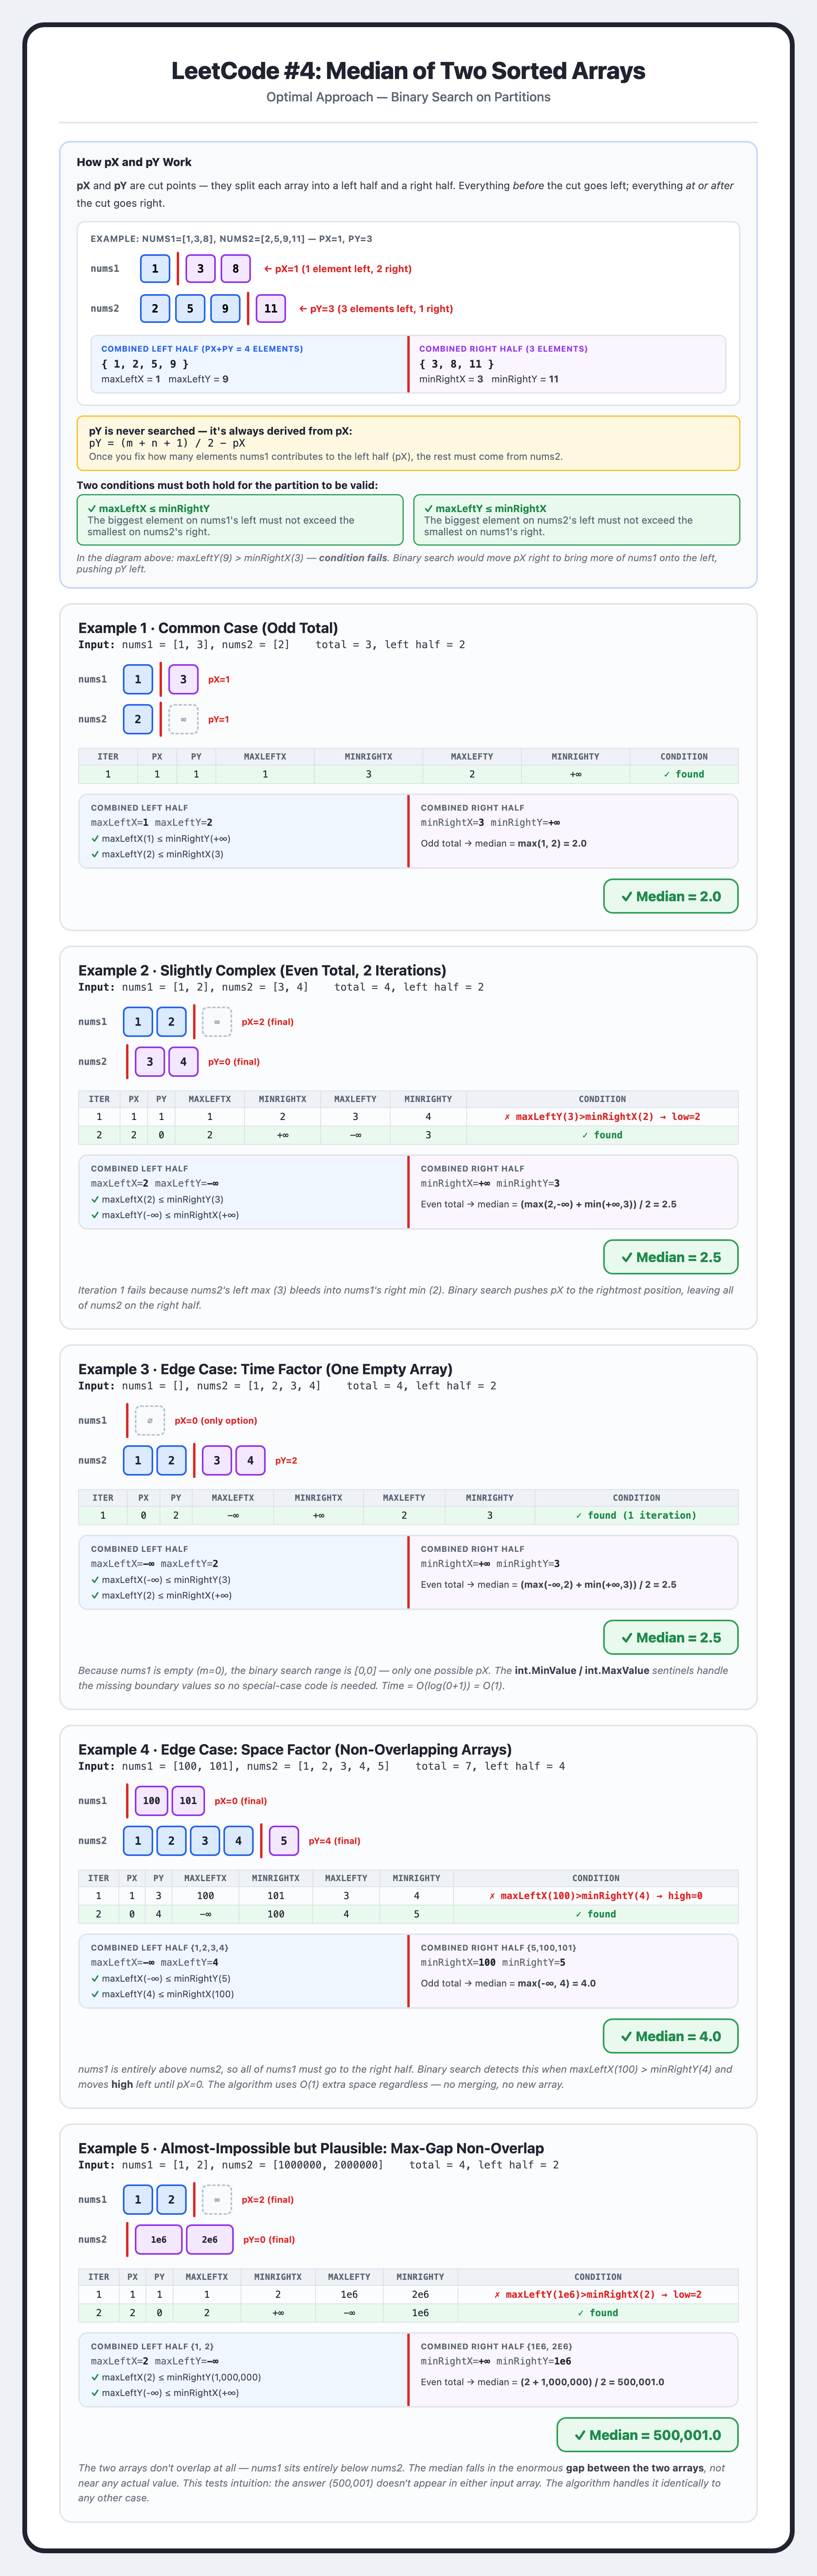